<a href="https://colab.research.google.com/github/risyadksm/PCVK_GANJIL_2025/blob/main/QUIZ1_PCVK_SOAL_NO_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import cv2
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [21]:
print("Upload gambar Anda:")
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
print(f"File terupload: {image_name}")

Upload gambar Anda:


Saving human.jpg to human (1).jpg
File terupload: human (1).jpg


Ukuran asli: 1920x1280 pixels
Hasil: 1920x1080 pixels


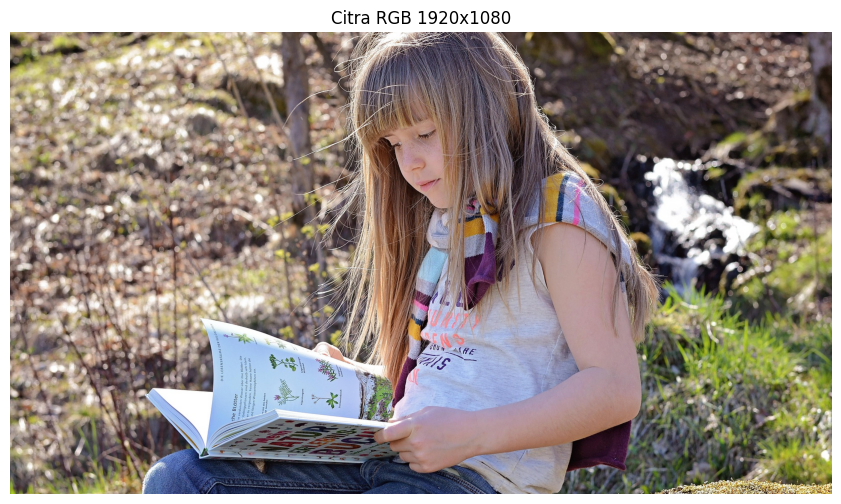

In [24]:
image_bgr = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Ukuran asli: {image_rgb.shape[1]}x{image_rgb.shape[0]} pixels")

# Resize/crop ke 1920x1080
target_width, target_height = 1920, 1080
height, width = image_rgb.shape[:2]

# Resize dengan mempertahankan aspek ratio
if width < target_width or height < target_height:
    scale = max(target_width/width, target_height/height)
    new_width = int(width * scale)
    new_height = int(height * scale)
    image_rgb = cv2.resize(image_rgb, (new_width, new_height))

# Crop ke 1920x1080 dari tengah
h, w = image_rgb.shape[:2]
start_x = (w - target_width) // 2
start_y = (h - target_height) // 2
rgb_1920x1080 = image_rgb[start_y:start_y+target_height, start_x:start_x+target_width]

print(f"Hasil: {rgb_1920x1080.shape[1]}x{rgb_1920x1080.shape[0]} pixels")

# Tampilkan gambar
plt.figure(figsize=(12, 6))
plt.imshow(rgb_1920x1080)
plt.title('Citra RGB 1920x1080')
plt.axis('off')
plt.show()

Resize 50%: 960x540 pixels
Resize 25%: 480x270 pixels


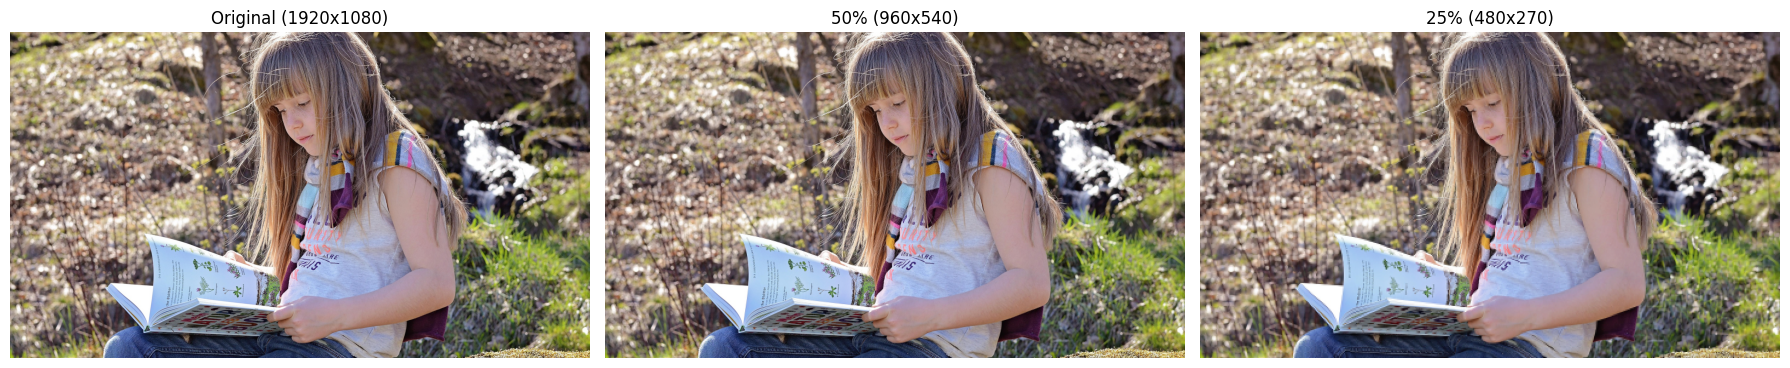

In [25]:
# Resize ke 50%
resize_50 = cv2.resize(rgb_1920x1080, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
print(f"Resize 50%: {resize_50.shape[1]}x{resize_50.shape[0]} pixels")

# Resize ke 25%
resize_25 = cv2.resize(rgb_1920x1080, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
print(f"Resize 25%: {resize_25.shape[1]}x{resize_25.shape[0]} pixels")

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_1920x1080)
axes[0].set_title('Original (1920x1080)')
axes[0].axis('off')

axes[1].imshow(resize_50)
axes[1].set_title('50% (960x540)')
axes[1].axis('off')

axes[2].imshow(resize_25)
axes[2].set_title('25% (480x270)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

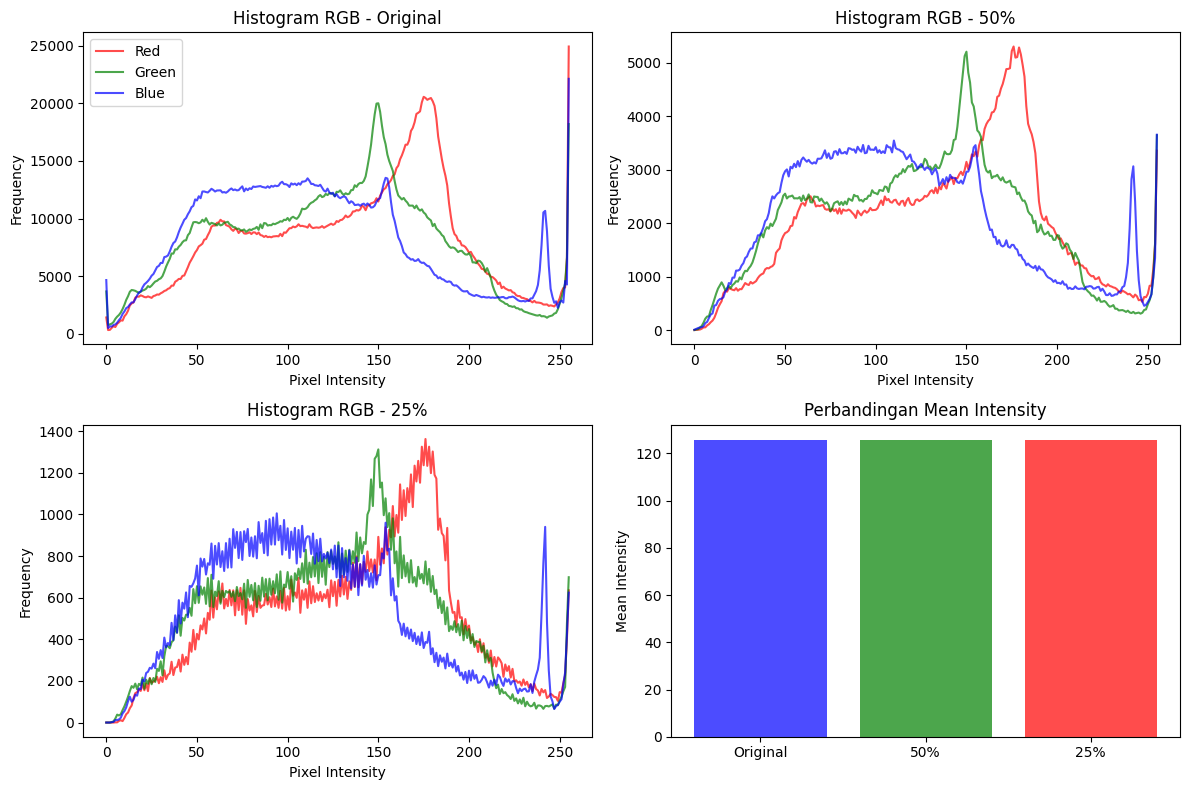

In [35]:
# Plot histogram RGB
plt.figure(figsize=(12, 8))

# Histogram untuk setiap channel
colors = ['red', 'green', 'blue']
plt.subplot(2, 2, 1)
for i, color in enumerate(colors):
    hist = cv2.calcHist([rgb_1920x1080], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, alpha=0.7, label=f'{color.capitalize()}')
plt.title('Histogram RGB - Original')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()

# Histogram gambar 50%
plt.subplot(2, 2, 2)
for i, color in enumerate(colors):
    hist = cv2.calcHist([resize_50], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, alpha=0.7)
plt.title('Histogram RGB - 50%')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

# Histogram gambar 25%
plt.subplot(2, 2, 3)
for i, color in enumerate(colors):
    hist = cv2.calcHist([resize_25], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, alpha=0.7)
plt.title('Histogram RGB - 25%')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

# Perbandingan mean intensity
plt.subplot(2, 2, 4)
sizes = ['Original', '50%', '25%']
images = [rgb_1920x1080, resize_50, resize_25]
mean_intensities = [np.mean(img) for img in images]

plt.bar(sizes, mean_intensities, color=['blue', 'green', 'red'], alpha=0.7)
plt.title('Perbandingan Mean Intensity')
plt.ylabel('Mean Intensity')

plt.tight_layout()
plt.show()

In [29]:
from google.colab import drive
drive.mount('/content/drive')

output_dir = "/content/drive/MyDrive/PCVK/QUIZ1/OUTPUT/"
os.makedirs(output_dir, exist_ok=True)

def save_image_formats(image, prefix, output_dir=output_dir):
    "Simpan gambar dalam 3 format ke Google Drive"
    # Convert RGB ke BGR untuk OpenCV
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    files = {}

    # JPEG
    jpeg_file = os.path.join(output_dir, f'{prefix}.jpg')
    cv2.imwrite(jpeg_file, image_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
    files['JPEG'] = jpeg_file

    # PNG
    png_file = os.path.join(output_dir, f'{prefix}.png')
    cv2.imwrite(png_file, image_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 9])
    files['PNG'] = png_file

    # TIFF
    tiff_file = os.path.join(output_dir, f'{prefix}.tiff')
    cv2.imwrite(tiff_file, image_bgr)
    files['TIFF'] = tiff_file

    return files

# 2. Simpan hasil resize ke Google Drive
files_50 = save_image_formats(resize_50, 'resize_50percent')
print("Gambar 50% disimpan ke Google Drive:")
for format_name, filename in files_50.items():
    print(f"  {format_name}: {filename}")

files_25 = save_image_formats(resize_25, 'resize_25percent')
print("\nGambar 25% disimpan ke Google Drive:")
for format_name, filename in files_25.items():
    print(f"  {format_name}: {filename}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Gambar 50% disimpan ke Google Drive:
  JPEG: /content/drive/MyDrive/PCVK/QUIZ1/OUTPUT/resize_50percent.jpg
  PNG: /content/drive/MyDrive/PCVK/QUIZ1/OUTPUT/resize_50percent.png
  TIFF: /content/drive/MyDrive/PCVK/QUIZ1/OUTPUT/resize_50percent.tiff

Gambar 25% disimpan ke Google Drive:
  JPEG: /content/drive/MyDrive/PCVK/QUIZ1/OUTPUT/resize_25percent.jpg
  PNG: /content/drive/MyDrive/PCVK/QUIZ1/OUTPUT/resize_25percent.png
  TIFF: /content/drive/MyDrive/PCVK/QUIZ1/OUTPUT/resize_25percent.tiff


In [36]:
print("UKURAN FILE")
print("="*50)

all_files = {**files_50, **files_25}

for filename in os.listdir('output'):
    filepath = os.path.join('output', filename)
    if os.path.isfile(filepath):
        size_bytes = os.path.getsize(filepath)
        size_kb = size_bytes / 1024
        print(f"{filename:20} | {size_kb:8.2f} KB | {size_bytes:8} bytes")

# Analisis perbandingan ukuran
print(f"\nPERBANDINGAN FORMAT:")
formats = ['jpg', 'png', 'tiff']
for fmt in formats:
    files_fmt = [f for f in os.listdir('output') if f.endswith(f'.{fmt}')]
    if files_fmt:
        avg_size = np.mean([os.path.getsize(f'output/{f}') for f in files_fmt])
        print(f"{fmt.upper():5}: {avg_size/1024:8.2f} KB rata-rata")

UKURAN FILE
resize_25percent.png |   274.63 KB |   281222 bytes
resize_25percent.tiff |   349.57 KB |   357956 bytes
resize_50percent.png |  1011.09 KB |  1035361 bytes
resize_50percent.jpg |   266.33 KB |   272727 bytes
resize_50percent.tiff |  1232.71 KB |  1262298 bytes
resize_25percent.jpg |    78.44 KB |    80319 bytes

PERBANDINGAN FORMAT:
JPG  :   172.39 KB rata-rata
PNG  :   642.86 KB rata-rata
TIFF :   791.14 KB rata-rata
